In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
%matplotlib inline

## Άσκηση - Ο μετασχηματισμός Fourier όπως χρησιμοποιείται στη βιομηχανία και την έρευνα

Αν λύσατε τις υπόλοιπες ασκήσεις σε αυτόν τον κατάλογο, θα είδατε ότι χρησιμοποιήσαμε έναν customized μετασχηματισμό Fourier. Θα ήταν πολύ περίεργο να μην υπάρχει κάποιο πιο "άμεσος"/εύκολος τρόπος να υλοποιεί κανείς το μετασχηματισμό Fourier χρησιμοποιώντας απ' ευθείας ένα δειγματοληπτημένο σήμα - χωρίς να χρειάζεται να κάνει ρητά δειγματοληψία στον άξονα του χρόνου και της συχνότητας, να κατασκευάζει πίνακες M, και να υλοποιεί αυτά τα περίεργα αθροίσματα Riemann που είδατε στις προηγούμενες ασκήσεις.

Ας υποθέσουμε λοιπόν ότι έχουμε το ψηφιακό σήμα αποθηκευμένο στον υπολογιστή μας (είτε είναι ομιλία, είτε μουσική, είτε εγκεφαλογράφημα, καρδιογράφημα, ή οποιαδήποτε άλλη χρονοσειρά). Αυτό σημαίνει ότι έχουμε στα χέρια μας το δειγματοληπτημένο σήμα $x[n] = x(t_n), n = 0, \cdots, N-1$ (που δεν είναι το ίδιο με το ψηφιακό σήμα, που αποτελείται από bits, αλλά ας αφήσουμε στην άκρη αυτή τη λεπτομέρεια). Ως τώρα προσεγγίσαμε το μετασχ. Fourier με το άθροισμα Riemann, κι επειδή εδώ έχουμε αποθηκευμένες μόλις $N$ τιμές του σήματος συνεχούς χρόνου, το άθροισμα αυτό θα γράφεται ως 

$$X(f) \approx \sum_{n=0}^{N-1}x(t_n)e^{-j2\pi f t_n}\Delta t$$

το οποίο απλοποιείται ως

$$X(f) \approx \Delta t \sum_{n=0}^{N-1}x[n]e^{-j2\pi f t_n}$$

Ξέρουμε ότι οι χρονικές στιγμές $t_n$ έχουν παρθεί ομοιόμορφα στον άξονα του χρόνου ανά $\Delta t$, δηλ.

$$t_n = n\Delta t, \: n \in \Z$$

οπότε

$$X(f) \approx \Delta t\sum_{n=0}^{N-1}x[n]e^{-j2\pi f n\Delta t}$$



Όπως πριν, δειγματοληπτούμε και τον άξονα της συχνότητας, **αλλά αυτή τη φορά**:

1. Επιλέγουμε $N_s$ σημεία του φάσματος, περισσότερα ή όσα ακριβώς είναι το πλήθος των δειγμάτων στο πεδίο του χρόνου ($N_s \geq N$). 
2. Έστω $N_s = N$ για το υπόλοιπο της συζήτησης.
3. Οι συχνότητες που επιλέγουμε απέχουν μεταξύ τους $\Delta f$, δηλ. η δειγματοληψία του φάσματος είναι κι εδώ ομοιόμορφη.

Με άλλα λόγια, οι συχνότητες που επιλέξαμε ισούνται με

$$f_k = \frac{k}{N}\Delta f = \frac{k}{N}\frac{1}{\Delta t}$$

Έτσι, ο μετασχηματισμός γράφεται ως

$$X(f_k) \approx \Delta t \sum_{n=0}^{N-1}x[n]e^{-j2\pi \frac{k}{N}\frac{1}{\Delta t}n\Delta t} = \Delta t \sum_{n=0}^{N-1}x[n]e^{-j2\pi \frac{k}{N}n}$$

δηλ.

$$X(f_k) \approx \Delta t X[k]$$

με $X[k]$ να είναι ένας εύκολα υπολογίσιμος μετασχηματισμός που ονομάζεται **Διακριτός Μετασχηματισμός Fourier**:

$$X[k] = \sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}, \: k = 0, \cdots, N-1$$

Ο Διακριτός Μετασχηματισμός Fourier είναι επίσης πολύ γρήγορα υπολογίσιμος μέσω του αλγορίθμου του **Γρήγορου Μετασχηματισμού Fourier (Fast Fourier Transform - FFT, https://www.youtube.com/watch?v=nmgFG7PUHfo)**, που σχεδόν όλες οι γλώσσες προγραμματισμού διαθέτουν μέσω εξειδικευμένων πακέτων ανάλυσης δεδομένων. Δηλ.

$$X(f_k) \approx \Delta t \: \textrm{FTT}\{x[n]\} = \Delta t \: X[k]$$

Ως επίδειξη, ας επαναλάβουμε την Άσκηση $\texttt{Ex-FourierTransformApproach}$ χρησιμοποιώντας τώρα τη συνάρτηση ``fft`` του υποπακέτου ``fft`` της ``NumPy``:

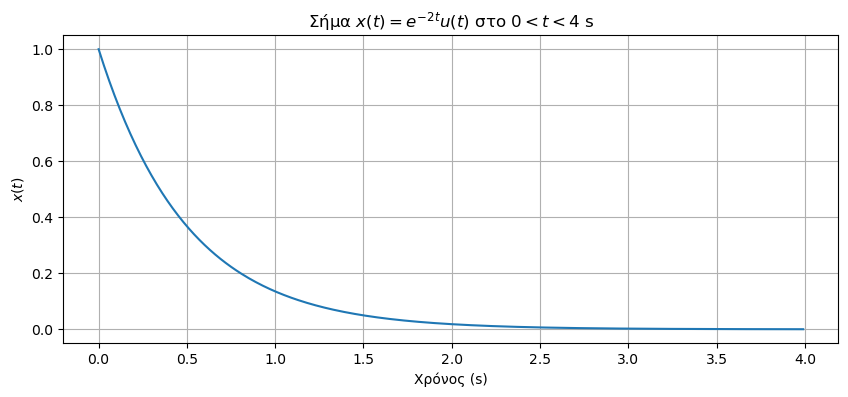

In [7]:
dt = 1e-2                  # Βήμα στο χρόνο
t = np.arange(0, 4.0, dt)  # Άξονας χρόνου, από 0 ως 4 δευτερόλεπτα
x = np.exp(-2*t)           # Σήμα e^{-2t}

N = len(x)                 # Ν = μήκος σήματος

plt.figure(figsize=(10, 4))
plt.plot(t, x)
plt.xlabel('Χρόνος (s)')
plt.ylabel(r'$x(t)$')
plt.title(r'Σήμα $x(t)=e^{-2t}u(t)$ στο $0 < t < 4$ s')
plt.grid(True)
plt.show()

Ως εδώ, όλα είναι ίδια με πριν. Δεν υπάρχει κάποια αλλαγή στον κώδικα σε σχέση με την προαναφερθείσα άσκηση (με εξαίρεση ότι κρατήσαμε 4 δευτερόλεπτα του σήματος αντί για 10, που θα έχει μικρή επίπτωση στο αποτέλεσμα).

Πάμε τώρα να κάνουμε την ανάλυση Fourier αποκλειστικά με χρήση έτοιμων συναρτήσεων.

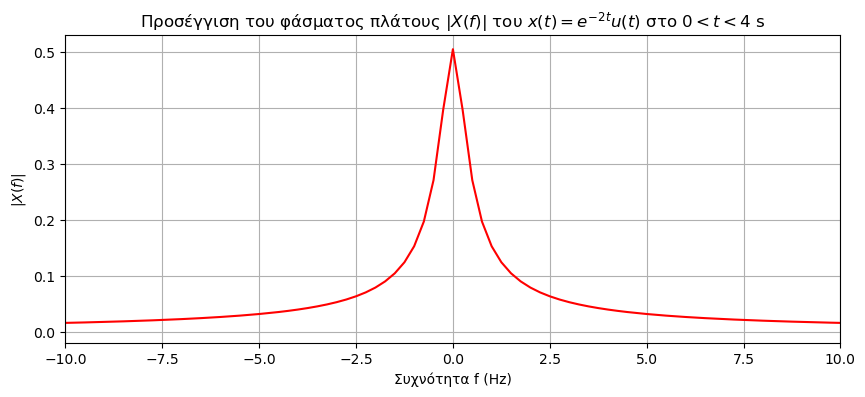

In [8]:
X = dt * np.fft.fft(x, N)      # X(f) ~ Δt X[k]: η προσέγγιση του X(f) μέσω του FFT X[k] από N σημεία
f = np.fft.fftfreq(N, d=dt)    # Άξονας συχνοτήτων όπως τον ορίσαμε παραπάνω - η συνάρτηση fftfreq τα κάνει όλα για μας!

# Ο μετασχηματισμός που επιστρέφεται χρειάζεται μια μικρή πράξη
# ώστε να εμφανίζεται σωστά - για λόγους που δεν είναι του παρόντος
# Η πράξη αυτή εκτελειται από τη συνάρτηση fftshift
X_shift = np.fft.fftshift(X)
f_shift = np.fft.fftshift(f)

# Τυπώνουμε το φάσμα πλάτους
plt.figure(figsize=(10, 4))
plt.plot(f_shift, np.abs(X_shift), 'r')
plt.xlabel('Συχνότητα f (Hz)')
plt.xlim([-10, 10])            # Kάνουμε zoom in στο διάστημα [-10, 10] Hz όπως στην 1η Άσκηση
plt.ylabel(r'$|X(f)|$')
plt.title(r'Προσέγγιση του φάσματος πλάτους $|X(f)|$ του $x(t)=e^{-2t}u(t)$ στο $0 < t < 4$ s')
plt.grid()
plt.show()

Συγκρίνετε το αποτέλεσμα με αυτό της Άσκησης $\texttt{Ex-FourierTransformApproach}$. Είναι ουσιαστικά το ίδιο!

---

Πώς θα χρησιμοποιούσαμε τον FFT ως προσέγγιση του μετασχ. Fourier που γνωρίζουμε για να λύσουμε την 5η άσκηση με το ηλεκτροεγκεφαλογράφημα? Ας το δούμε.

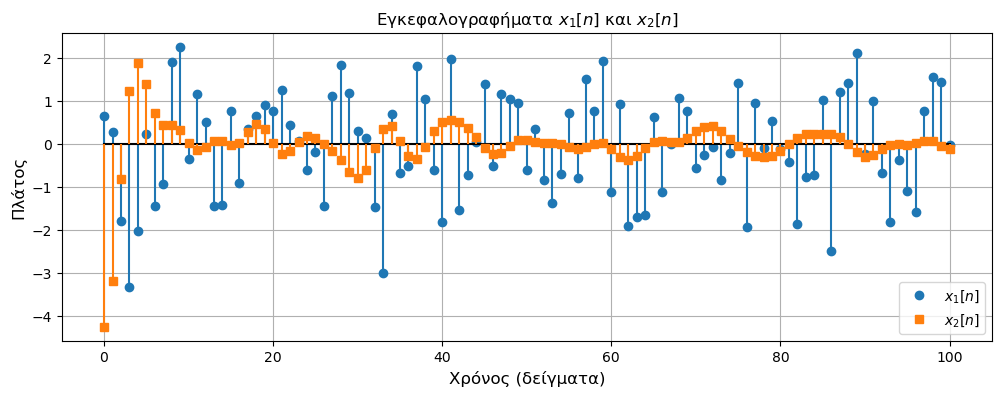

In [11]:
mat = loadmat('./files/EEGn.mat')  # Φορτώνουμε ξανά τα δεδομένα μας

x1 = np.array(np.squeeze(mat["x1"]))  # Χωρίζουμε τα δυο σήματα όπως πριν
x2 = np.array(np.squeeze(mat["x2"]))  # ------------- " -----------------
dt = np.array(np.squeeze(mat["dt"]))  # Tο βήμα μας στο χρόνο

N1 = len(x1)  # Οι διάρκειες σε δείγματα των σημάτων
N2 = len(x2)  # ----------------- " ----------------

n1 = np.arange(0, N1)   # Ο άξονας του διακριτού (!) χρόνου σε δείγματα
n2 = np.arange(0, N2)   # ------------ " -----------------------------

# Ας ξαναδούμε τα ηλεκτροεγκεφαλογραφήματα αλλά αυτή τη φορά στο διακριτό χρόνο (όπως είναι αποθηκευμένα στον υπολογιστή)!
# Δεν είναι απαραίτητο να το κάνετε αυτό, μπορείτε να κρατήσετε τα γραφήματα όπως τα κάνατε στην 5η άσκηση - απλά δείχνουμε μια εναλλακτική απεικόνιση.
fig, ax = plt.subplots(figsize=(12, 4))
m1, s1, b1 = ax.stem(n1, x1, linefmt='C0-', markerfmt='C0o', basefmt='k-')
m2, s2, b2 = ax.stem(n2, x2, linefmt='C1-', markerfmt='C1s', basefmt=' ')

m1.set_label(r'$x_1[n]$')
m2.set_label(r'$x_2[n]$')
ax.legend(loc='lower right')
ax.grid()
ax.set_xlabel('Χρόνος (δείγματα)', fontsize=12)
ax.set_ylabel('Πλάτος', fontsize=12)
ax.set_title('Εγκεφαλογραφήματα $x_1[n]$ και $x_2[n]$', fontsize=12)
plt.show()

Πάμε τώρα να υπολογίσουμε το φάσμα πλάτους καθενός σήματος για να ελέγξουμε την ύπαρξη ρυθμού Άλφα, αλλά αυτή τη φορά χρησιμοποιώντας τον αλγόριθμο FFT!

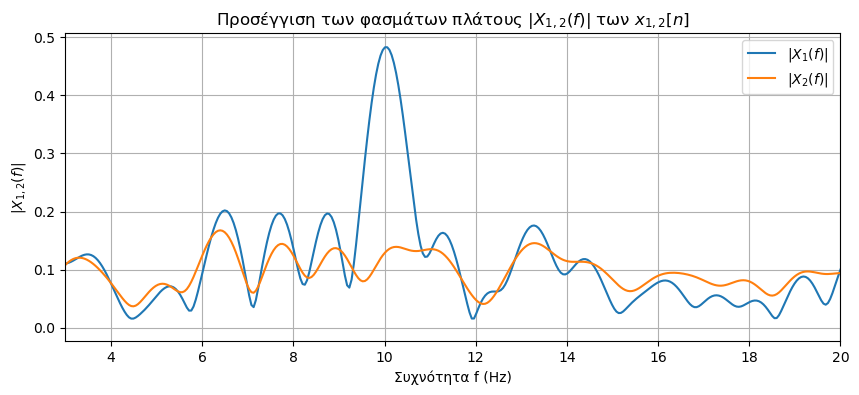

In [10]:
N = 2048                    # Σε αντίθεση με το προηγούμενο παράδειγμα, 
                            # επιλέγουμε να πάρουμε ΠΟΛΛΑ σημεία στο φάσμα του FFT, 
                            # ήτοι 2048 σημεία αντί για N = διάρκεια σημάτων στο χρόνο (που είναι μόλις 100)

X1 = dt * np.fft.fft(x1, N) # INSERT CODE HERE          # X1(f) ~ Δt X1[k]: η προσέγγιση του X1(f) μέσω του FFT X1[k]
f1 = np.fft.fftfreq(N, d=dt)     # Άξονας συχνοτήτων όπως τον ορίσαμε παραπάνω

X2 = dt * np.fft.fft(x2, N) # INSERT CODE HERE          # X2(f) ~ Δt X2[k]: η προσέγγιση του X2(f) μέσω του FFT X2[k]
f2 = np.fft.fftfreq(N, d=dt)     # Άξονας συχνοτήτων όπως τον ορίσαμε παραπάνω

# Καλούμε την fttshift να μας "φτιάξει" λίγο τα φάσματα όπως πρέπει
X1_shift = np.fft.fftshift(X1)
f1_shift = np.fft.fftshift(f1)
X2_shift = np.fft.fftshift(X2)
f2_shift = np.fft.fftshift(f2)

plt.figure(figsize=(10, 4))
plt.plot(f1_shift, np.abs(X1_shift), label="$|X_1(f)|$")
plt.plot(f2_shift, np.abs(X2_shift), label="$|X_2(f)|$")
plt.xlim([3, 20])                # Kάνουμε zoom in στο διάστημα που μας ενδιαφέρει για να ανιχνεύσουμε το ρυθμό Άλφα
plt.xlabel('Συχνότητα f (Hz)')
plt.ylabel(r'$|X_{1,2}(f)|$')
plt.legend()
plt.title(r'Προσέγγιση των φασμάτων πλάτους $|X_{1,2}(f)|$ των $x_{1,2}[n]$')
plt.grid(True)
plt.show()

Αν λοιπόν θέλετε να επεξεργαστείτε με το μετασχηματισμό Fourier σήματα συνεχούς χρόνου που έχετε αποθηκεύσει στον Η/Υ σας, θα χρησιμοποιήσετε τον αλγόριθμο FFT και τον τρόπο που δείχνουμε σε αυτήν την άσκηση.

Φυσικά, στην εξήγησή μας σχετικά με τον FFT υπάρχουν κάποια κενά στη θεωρία, που θα "κλείσουν" αν συνεχίσετε να διαβάζετε το βιβλίο και λύνετε τα επόμενα εργαστήρια.

---
---